In [109]:
import numpy as np
import pandas as pd

In [ ]:
#Before running the below code, datasets should be downloaded. For more info, check the README file

In [110]:
test=pd.read_csv('fashion-mnist_test.csv')
train=pd.read_csv('fashion-mnist_train.csv')
df=pd.concat([train,test],axis=0)

In [111]:
df.to_csv('fashion-mnist.csv',index=False)

In [112]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [113]:
df.shape

(70000, 785)

In [114]:
df.isnull().sum()

,0
label,0
pixel1,0
pixel2,0
pixel3,0
pixel4,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


In [115]:
df.fillna(0, inplace=True)

In [116]:
df.isnull().sum()

,0
label,0
pixel1,0
pixel2,0
pixel3,0
pixel4,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


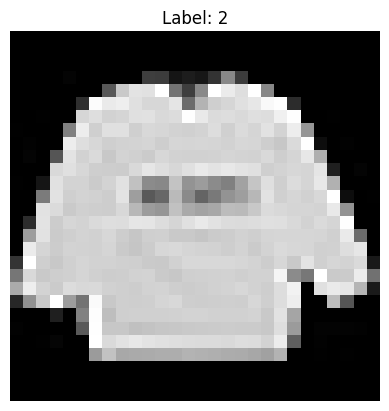

In [117]:
import matplotlib.pyplot as plt

# Select the first image and its label
image_index = 0
image_data = df.iloc[image_index, 1:].values.astype('uint8')
image_label = df.iloc[image_index, 0]

# Reshape the 784-pixel array to 28x28
image = image_data.reshape(28, 28)

# Display the image
plt.imshow(image, cmap='gray')
plt.title(f"Label: {image_label}")
plt.axis('off')
plt.show()

In [118]:
X=df.iloc[:,1:]
Y=df.iloc[:,0]
X=X/255

In [119]:
X.max().max()

1.0

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [121]:
X_train.shape

(56000, 784)

In [122]:
X_test.shape

(14000, 784)

In [86]:
!pip install keras-tuner --upgrade
import keras_tuner
import keras

In [123]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(hp):
    model = keras.Sequential()
    for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
      if i==0:
        model.add(Dense(
            units=hp.Int('units_'+str(i),min_value=8,max_value=128,step=8),
            activation=hp.Choice('activation'+str(i),values=['relu','sigmoid','tanh']),
            input_dim=784))
      else:
        model.add(Dense(units=hp.Int('units_' + str(i),
                                      min_value=32,
                                      max_value=512),
                  activation=hp.Choice('activation' + str(i),
                                       values=['relu', 'sigmoid', 'tanh']),
                  ))

    model.add(Dense(10, activation='softmax'))
    model.compile(
        optimizer=hp.Choice('optimizer', values=['sgd',
    'rmsprop',
    'adam',
    'adagrad',
    'adadelta',
    'adamax',
    'nadam',
    'ftrl']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [124]:
tuner=keras_tuner.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [125]:
tuner.search(X_train,y_train,epochs=5,validation_split=0.2)

Trial 10 Complete [00h 00m 30s]
val_accuracy: 0.1007142886519432

Best val_accuracy So Far: 0.8723214268684387
Total elapsed time: 00h 07m 27s


In [126]:
model = tuner.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 39 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [127]:
callback=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.01,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)

model.fit(X_train,y_train,epochs=200,initial_epoch=5,validation_split=0.3,callbacks=[callback])

Epoch 6/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8850 - loss: 0.3216 - val_accuracy: 0.8728 - val_loss: 0.3508
Epoch 7/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8897 - loss: 0.3053 - val_accuracy: 0.8797 - val_loss: 0.3459
Epoch 8/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8933 - loss: 0.2946 - val_accuracy: 0.8565 - val_loss: 0.3877
Epoch 9/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8958 - loss: 0.2880 - val_accuracy: 0.8796 - val_loss: 0.3332
Epoch 10/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8994 - loss: 0.2769 - val_accuracy: 0.8809 - val_loss: 0.3464
Epoch 11/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9026 - loss: 0.2705 - val_accuracy: 0.8644 - val_loss: 0.3866
Epoch 12/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9035 - loss: 0.2657 - val_accuracy: 0.8709 - val_loss: 0.3611
Epoch 13/200
1225/1225 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9052 - 

In [90]:
#only use this line if you want to remove untitled_project folder

# import shutil

# shutil.rmtree("untitled_project", ignore_errors=True)

In [128]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8786 - loss: 0.3421
Test Accuracy: 0.8786428570747375


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


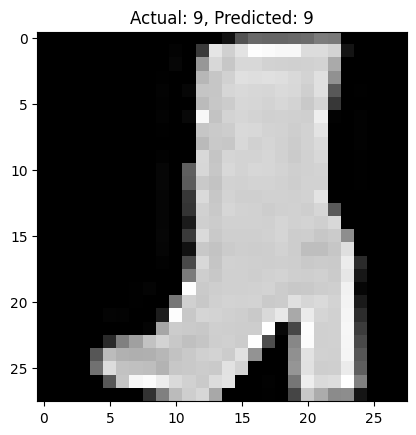

In [129]:
import matplotlib.pyplot as plt

index = 100
sample_image = X_test.iloc[index].values
actual_label = y_test.iloc[index]

prediction = model.predict(sample_image.reshape(1, 784))
predicted_label = np.argmax(prediction)

plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Actual: {actual_label}, Predicted: {predicted_label}")
plt.show()